In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from data_loader import load_data, add_rul
from features import run_feature_pipeline
from evaluate import evaluate

In [2]:
# Feature Engineering
train_df, test_df, rul_df = load_data(data_dir='../data/raw/CMaps')
train_df = add_rul(train_df)
train_df, test_df, scaler = run_feature_pipeline(train_df, test_df)
actuals = rul_df['RUL'].values
print("Data ready...")

After dropping useless cos: (20631, 19)
RUL clipped at 125. Max RUL: 125
After rolling features: (20631, 45)
After lag features: (20631, 84)
Normalization done.

 Final train shape: (20631, 84)

 Final test shape: (13096, 83)
Data ready...


In [5]:
# XGBoost
from models.xgboost_model import train as xgb_train, predict_test as xgb_predict, save_model as xgb_save, load_model as xgb_load
import joblib, os

if os.path.exists('../models/xgboost_rul.pkl'):
    print("Loading saved XGBoost model...")
    xgb_model = xgb_load('../models/xgboost_rul.pkl')
else:
    print("training XGBoost model...")
    xgb_model = xgb_train(train_df)
    xgb_save(xgb_model, '../models/xgboost_rul.pkl')

xgb_preds, _ = xgb_predict(xgb_model, test_df, rul_df)
xgb_results = evaluate(actuals, xgb_preds, model_name="XGBoost Baseline")


Loading saved XGBoost model...
   XGBoost Baseline Results: 
 
RMSE:        19.39 cycles
 
MAE:         13.97 cycles
 
NASA Score:  752.65 (lower is better)


In [6]:
# LSTM
import torch
from models.lstm_model import LSTMModel, train as lstm_train, predict_test as lstm_predict, save_model as lstm_save, create_sequence

if os.path.exists('../models/lstm_rul.pt'):
    print("Loading saved LSTM model...")
    # need input to rebuild model architecture
    feature_cols = [c for c in train_df.columns if c not in ['engine_id', 'cycle', 'RUL']]
    lstm_model = LSTMModel(input_size=len(feature_cols))
    lstm_model.load_state_dict(torch.load('../models/lstm_rul.pt'))
    lstm_model.eval()
else:
    print("Training LSTM...")
    lstm_model = lstm_train(train_df)
    lstm_save(lstm_model, '../models/lstm_rul.pt')

lstm_preds = lstm_predict(lstm_model, test_df)
lstm_results = evaluate(actuals, lstm_preds, model_name="LSTM")

Loading saved LSTM model...
   LSTM Results: 
 
RMSE:        15.19 cycles
 
MAE:         11.05 cycles
 
NASA Score:  367.96 (lower is better)


In [3]:
import torch
from models.transformer_model import TransformerModel, train as tf_train, predict_test as tf_predict, save_model as tf_save
import os

if os.path.exists('../models/transformer_rul.pt'):
    print("Loading saved transformer model...")
    feature_cols = [c for c in train_df.columns if c not in ['engine_id', 'cycle', 'RUL']]
    tf_model = TransformerModel(input_size=len(feature_cols))
    tf_model.load_state_dict(torch.load('../models/transformer_rul.pt', weights_only=True))
    tf_model.eval()
else:
    print("Training transformer...")
    tf_model = tf_train(train_df)
    tf_save(tf_model, '../models/transformer_rul.pt')

tf_preds = tf_predict(tf_model, test_df)
tf_results = evaluate(actuals, tf_preds, model_name="Transformer")

Training transformer...
Creating sequence...
Training sequence: (17731, 30, 81)
Training Trnaformer...
Epoch 10/9 - Loss: 199.4589
Epoch 20/19 - Loss: 182.0970
Epoch 30/29 - Loss: 178.8139
Epoch 40/39 - Loss: 164.6278
Epoch 50/49 - Loss: 159.8576
Epoch 60/59 - Loss: 150.5654
Model saved to ../models/transformer_rul.pt
   Transformer Results: 
 
RMSE:        14.97 cycles
 
MAE:         10.94 cycles
 
NASA Score:  343.87 (lower is better)


In [7]:
results = pd.DataFrame({
    'Model': ['XGBoost', 'LSTM', 'Transformer'],
    'RMSE': [xgb_results['rmse'], lstm_results['rmse'], tf_results['rmse']],
    'MAE': [xgb_results['mae'], lstm_results['mae'], tf_results['mae']],
    'NASA Score': [xgb_results['nasa_score'], lstm_results['nasa_score'], tf_results['nasa_score']]
}).round(2)

print(results.to_string(index=False))

# Save results to CSV
results.to_csv('../data/processed/model_results.csv', index=False)
print("\nResults saved to data/processed/model_results.csv")

      Model  RMSE   MAE  NASA Score
    XGBoost 19.39 13.97      752.65
       LSTM 15.19 11.05      367.96
Transformer 14.97 10.94      343.87

Results saved to data/processed/model_results.csv


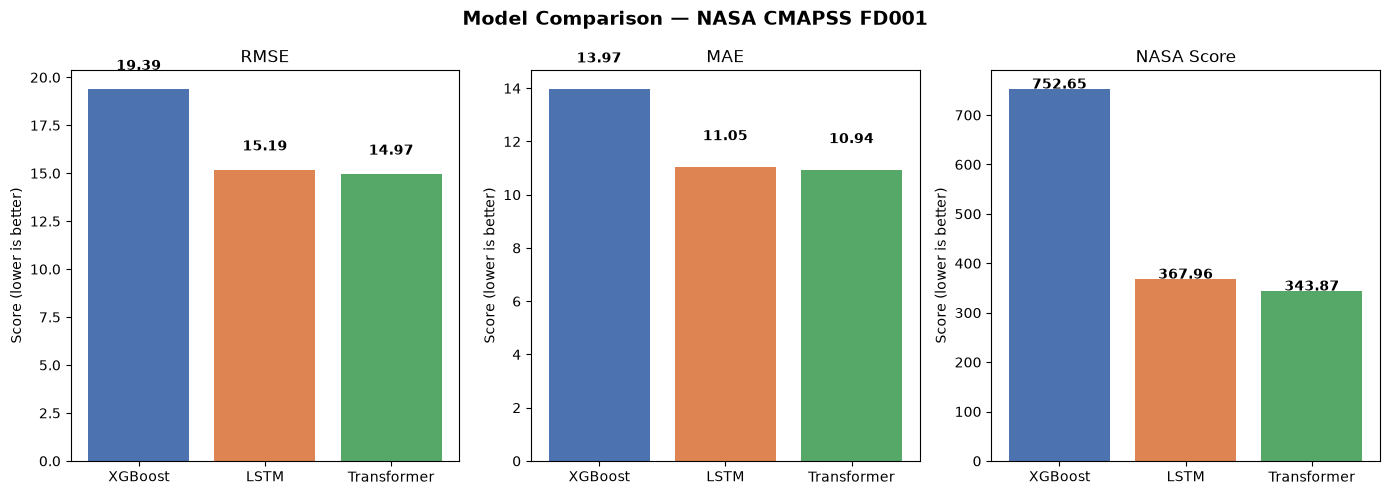

Plot saved.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['RMSE', 'MAE', 'NASA Score']
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylabel('Score (lower is better)')
    for j, v in enumerate(results[metric]):
        axes[i].text(j, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Model Comparison — NASA CMAPSS FD001', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")